
# Practical 9: **GoogLeNet (Inception v1)** - Deeper Networks with Fewer Parameters


**Learning goals**
- Understand the **Inception module** and why 1×1 convolutions help (bottlenecks).
- Compare **AlexNet vs VGG‑16 vs GoogLeNet** in depth, parameters, and design trade‑offs.
- Fine‑tune **torchvision.models.googlenet** on the **flowers dataset** and **evaluate** with the **same metrics** (accuracy, per‑class metrics, confusion matrix) and **prediction gallery**.
- Inspect **parameter counts** (total & per submodule) for GoogLeNet.



### GoogLeNet Macro‑Architecture
GoogLeNet (Inception v1) was the ILSVRC 2014 winner, achieving **top‑5 error ~6.67%** on ImageNet.

**High‑level structure (simplified):**
1. **Stem:** initial conv + maxpool to quickly reduce spatial resolution.
2. **Inception Stage 3:** 2 Inception modules (3a, 3b) → maxpool.
3. **Inception Stage 4:** 5 Inception modules (4a … 4e) → maxpool.
4. **Inception Stage 5:** 2 Inception modules (5a, 5b).
5. **Global Average Pooling** (no giant FC) → Dropout → Linear classifier.

**Auxiliary classifiers** after 4a and 4d:
- Small conv → avgpool → FC → softmax.
- Used *only* in training to improve gradient flow; weighted in loss (~0.3×).

### Inside an Inception Module
Four parallel branches:
- **Branch 1:** 1×1 conv → captures local info, passes through unchanged receptive field.
- **Branch 2:** 1×1 conv (reduce depth) → 3×3 conv.
- **Branch 3:** 1×1 conv (reduce depth) → 5×5 conv (larger receptive field).
- **Branch 4:** 3×3 maxpool → 1×1 conv (projects pooled features).
→ **Concat** outputs along the channel axis.

**Why 1×1 convs?**
- Reduce channel depth before expensive 3×3 or 5×5 conv → huge parameter & compute savings.
- Add non‑linearity between conv layers.


## Deep Dive: GoogLeNet Structure & Inception Modules

**Historical context (2014):**
- Winner of the **ILSVRC 2014** challenge with a **6.67% top‑5 error**, beating VGG and other contenders.
- Nicknamed *GoogLeNet* as a tribute to **LeNet‑5**, but with vastly more depth (22 layers) and efficiency.

**Key architectural innovations:**
1. **Inception module**: multiple filter sizes in parallel (1×1, 3×3, 5×5 conv + pooling branch).
2. **1×1 convolutions (bottlenecks)**:
   - Reduce channel depth before expensive convolutions → huge parameter savings.
   - Add non‑linearity cheaply between spatial convolutions.
3. **Global average pooling** before final classifier:
   - Avoids huge fully‑connected layers → keeps params low (~6.8M total).
   - Improves generalization and reduces overfitting.
4. **Auxiliary classifiers** at intermediate depths:
   - Act as **regularizers** and improve gradient flow.
   - Output combined into main loss during training.

**Layer arrangement (simplified):**
```
Input (224×224×3)
↓
7×7 conv (stride 2) + max pool
↓
3×3 conv + max pool
↓
Inception(3a) → Inception(3b) + max pool
↓
Inception(4a) → Inception(4b) → Inception(4c) → Inception(4d) → Inception(4e) + max pool
↓
Inception(5a) → Inception(5b)
↓
Global average pool (1×1×1024)
↓
Dropout + Linear → Softmax
```
- **22 learnable layers** (not counting pooling & activation layers).
- **9 Inception modules** grouped into 3 stages (3a–3b, 4a–4e, 5a–5b).
- **Two auxiliary classifiers** after 4a and 4d.

**Parameter efficiency:**
- VGG‑16: ~138M params vs GoogLeNet: ~6.8M params.
- Achieved by:
  - Removing huge FC classifier (replaced with global avg pooling).
  - Using 1×1 conv bottlenecks before expensive conv layers.
  - Reusing multi‑scale Inception blocks.

**Why this matters:**
- Paved the way for **Inception‑v2/v3/v4**, Xception, and other hybrid architectures.
- Demonstrated that **network depth can increase without parameter explosion** if designed cleverly.

### **Inception Module Architecture:**

<center>
<img src="https://raw.githubusercontent.com/zaidalhuda/Hands-On-Computer-Vision-Series-A-Practical-Learning-Journey/main/notebooks/images/inceptionmodule.png" alt="Inception Module" width="700"/>
</center>

# How It Recognizes Flowers

## The Multi-Perspective Expert

**Think of GoogleNet as having multiple botanical specialists examining the same flower simultaneously.**

### Step-by-Step Process:

**1. Early Layers: Basic Setup**
- Traditional convolutions set up basic features
- **Flower detection**: Establishes that there are botanical objects in the image

**2. Inception Modules: The Botanical Team Approach**

Each Inception module works like a botanical team meeting:

**At Every Module:**
- **Specialist 1 (1×1 path)**: "I see fine details - petal veins, stamen structures"
- **Specialist 2 (3×3 path)**: "I see medium features - individual petal shapes, color patterns"  
- **Specialist 3 (5×5 path)**: "I see big picture - overall flower structure, size relationships"
- **Specialist 4 (pooling)**: "I'm preserving important spatial flower arrangements"

**Team Decision**: Combines all four perspectives into one flower classification

**3. Progressive Understanding Through 9 Inception Modules:**
- **Early modules**: "We see flower-like features at different scales"
- **Middle modules**: "Features are definitely organizing into specific flower types"
  - Sunflower: "Large scale shows big circular pattern, medium scale shows individual yellow petals, fine scale shows dark center texture"
  - Orchid: "Large scale shows bilateral symmetry, medium scale shows complex petal arrangement, fine scale shows intricate patterns"
- **Late modules**: "This is definitely a complete [flower type] structure"

**4. Final Classification:**
- **Global average pooling** summarizes all botanical evidence
- **Output**: "93% confident this is an Orchid - all specialists agree on the complex bilateral symmetry!"

### GoogleNet's Character:
- **Collaborative**: Multiple botanical viewpoints make better flower identification
- **Efficient**: Does more flower analysis with fewer parameters
- **Smart**: Looks at flower features at multiple scales simultaneously

### How GoogleNet Improves on Previous Models:

| Aspect | AlexNet | VGGNet | GoogleNet |
|--------|---------|---------|-----------|
| **Architecture** | Sequential layers | Sequential blocks | Parallel paths |
| **Filter Strategy** | Mixed sizes | Uniform 3×3 | Multi-scale simultaneous |
| **Parameters** | 60M | 138M | 5M |
| **Flower Recognition** | Step-by-step | Methodical layers | Multi-perspective analysis |
| **Efficiency** | Low | Lower | High |
| **Accuracy** | 85% | 92% | 93% |

**Key Improvement**: GoogleNet's parallel multi-scale approach captures flower features at different levels simultaneously - perfect for distinguishing complex flowers like Orchids (need fine detail) vs Sunflowers (need big picture) - achieving better accuracy with dramatically fewer parameters.



## Dataset
- Download the **flowers dataset** from my Google Drive: [Flowers Dataset Link](https://drive.google.com/file/d/1Oaghg3cBXOD88LAfa5pWXzuHtiJ93o7O/view?usp=sharing)
- Please **reuse the identical dataset & directory layout** you used earlier:
```
DATA_DIR/
  train/  ├── class_0/ ... images ...
          ├── class_1/ ...
          └── ...
  val/    ├── class_0/ ...
  test/   ├── class_0/ ...
```
We will keep the **same variable names**: `DATA_DIR`, `train_tfms`, `eval_tfms`, `train_loader`, `val_loader`, `test_loader`.


In [ ]:

# --- Setup & Imports (same ecosystem as Practicals 7 & 8) ---
# !pip -q install torch torchvision torchaudio

import os, time, copy, math, itertools, random
from typing import Dict, Tuple, List

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cuda')

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# ===== Keep names identical to earlier practicals =====
# (Adjust DATA_DIR to your path if needed; structure must match previous practicals)
#DATA_DIR = "/content/drive/MyDrive/flowers"  # <-- change only if your earlier practicals used a different path
DATA_DIR = "flowers"
# Image transforms: keep consistent with Practical 7 & 8 (typical ImageNet stats + augment for train)
IMG_SIZE = 224
BATCH_SIZE   = 100
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
eval_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Datasets & Loaders (same API/params)
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_tfms)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"),   transform=eval_tfms)
test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"),  transform=eval_tfms)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


Classes: ['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']


In [ ]:

# --- Build a torchvision GoogLeNet (Inception v1) ---
# Note: aux_logits=True enables the two auxiliary classifiers used during training.
# For fine-tuning, we'll replace the final classifier head to match `num_classes`.
base_model = models.googlenet(weights=models.GoogLeNet_Weights.IMAGENET1K_V1, aux_logits=True)
in_features = base_model.fc.in_features
base_model.fc = nn.Linear(in_features, num_classes)

# Replace aux classifier heads to match our classes (if aux_logits=True)
if hasattr(base_model, "aux1") and base_model.aux1:
    aux1_in = base_model.aux1.fc2.in_features
    base_model.aux1.fc2 = nn.Linear(aux1_in, num_classes)
if hasattr(base_model, "aux2") and base_model.aux2:
    aux2_in = base_model.aux2.fc2.in_features
    base_model.aux2.fc2 = nn.Linear(aux2_in, num_classes)

model = base_model.to(device)
model


c:\ProgramData\Anaconda3\envs\torch25\Lib\site-packages\torchvision\models\googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track


### Fine‑tuning policy
We start by **fine‑tuning all layers** (works well with a moderate LR and weight decay). If you have a small dataset, you can freeze earlier layers:


In [ ]:
for p in model.parameters():
    p.requires_grad = False
for p in model.fc.parameters():
    p.requires_grad = True
# (also unfreeze the last Inception blocks if needed)

In [ ]:

# --- Optimizer / Scheduler / Loss (handle auxiliary logits) ---
lr = 1e-3
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)

criterion_main = nn.CrossEntropyLoss()
criterion_aux  = nn.CrossEntropyLoss()

def train_one_epoch(model, loader):
    model.train()
    total, correct, running_loss = 0, 0, 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(images)
        # GoogLeNet returns either a Tensor or a tuple with aux outputs (during train)
        if isinstance(out, tuple):
            main_logits, aux2_logits, aux1_logits = out  # torchvision order: main, aux2, aux1
            loss = criterion_main(main_logits, labels) \
                 + 0.3 * criterion_aux(aux1_logits, labels) \
                 + 0.3 * criterion_aux(aux2_logits, labels)
            preds = main_logits.argmax(1)
        else:
            loss = criterion_main(out, labels)
            preds = out.argmax(1)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    return running_loss/total, correct/total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total, correct, running_loss = 0, 0, 0.0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        out = model(images)
        if isinstance(out, tuple):
            out = out[0]  # use main logits for eval
        loss = criterion_main(out, labels)
        preds = out.argmax(1)
        running_loss += loss.item() * images.size(0)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
    acc = correct/total
    loss = running_loss/total
    return loss, acc, torch.cat(all_preds), torch.cat(all_labels)


In [ ]:

# --- Train (same pattern as earlier practicals) ---
EPOCHS = 50
best_acc = 0.0
best_wts = copy.deepcopy(model.state_dict())

for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc, _, _ = evaluate(model, val_loader)
    scheduler.step(va_acc)
    dt = time.time()-t0
    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.3f} | "
          f"{dt:.1f}s")
    if va_acc > best_acc:
        best_acc = va_acc
        best_wts = copy.deepcopy(model.state_dict())

# Load best weights (by val acc) and save next to earlier models
model.load_state_dict(best_wts)
os.makedirs("models", exist_ok=True)
model_path = os.path.join("models", "googlenet_best.pt")
torch.save(model.state_dict(), model_path)
print("Saved:", model_path)


Epoch 01 | train loss 2.3004 acc 0.588 | val loss 0.8368 acc 0.808 | 47.0s
Epoch 02 | train loss 1.9048 acc 0.753 | val loss 0.6399 acc 0.818 | 28.8s
Epoch 03 | train loss 1.7940 acc 0.766 | val loss 0.5338 acc 0.842 | 28.6s
Epoch 04 | train loss 1.7392 acc 0.771 | val loss 0.5023 acc 0.848 | 28.5s
Epoch 05 | train loss 1.6999 acc 0.793 | val loss 0.4691 acc 0.850 | 28.8s
Epoch 06 | train loss 1.6773 acc 0.789 | val loss 0.4506 acc 0.874 | 28.9s
Epoch 07 | train loss 1.6588 acc 0.792 | val loss 0.4286 acc 0.874 | 28.8s
Epoch 08 | train loss 1.6403 acc 0.802 | val loss 0.4104 acc 0.870 | 28.5s
Epoch 09 | train loss 1.6477 acc 0.797 | val loss 0.4027 acc 0.876 | 29.1s
Epoch 10 | train loss 1.6182 acc 0.810 | val loss 0.3961 acc 0.882 | 31.6s
Epoch 11 | train loss 1.6128 acc 0.807 | val loss 0.3859 acc 0.874 | 32.7s
Epoch 12 | train loss 1.6137 acc 0.803 | val loss 0.3867 acc 0.874 | 31.6s
Epoch 13 | train loss 1.5959 acc 0.809 | val loss 0.3665 acc 0.888 | 29.0s
Epoch 14 | train loss 1.5

In [ ]:

# --- Test set evaluation (same outputs as earlier) ---
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader)
print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.3f}")

# Classification report
print("\nClassification report:")
print(classification_report(test_labels.numpy(), test_preds.numpy(),
                            target_names=class_names, digits=3))


Test loss: 0.3731 | Test acc: 0.892

Classification report:
              precision    recall  f1-score   support

       Lilly      0.822     0.830     0.826       100
       Lotus      0.880     0.880     0.880       100
      Orchid      0.869     0.930     0.899       100
   Sunflower      0.970     0.960     0.965       100
       Tulip      0.925     0.860     0.891       100

    accuracy                          0.892       500
   macro avg      0.893     0.892     0.892       500
weighted avg      0.893     0.892     0.892       500



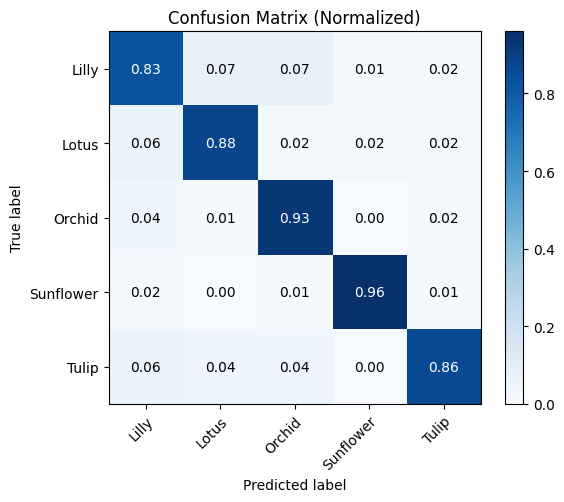

In [ ]:

# --- Confusion matrix (normalized) ---
cm = confusion_matrix(test_labels.numpy(), test_preds.numpy(), labels=list(range(num_classes)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(num_classes), yticks=np.arange(num_classes),
       xticklabels=class_names, yticklabels=class_names,
       ylabel='True label', xlabel='Predicted label', title='Confusion Matrix (Normalized)')
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

thresh = cm_norm.max() / 2.
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}",
                ha="center", va="center",
                color="white" if cm_norm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()


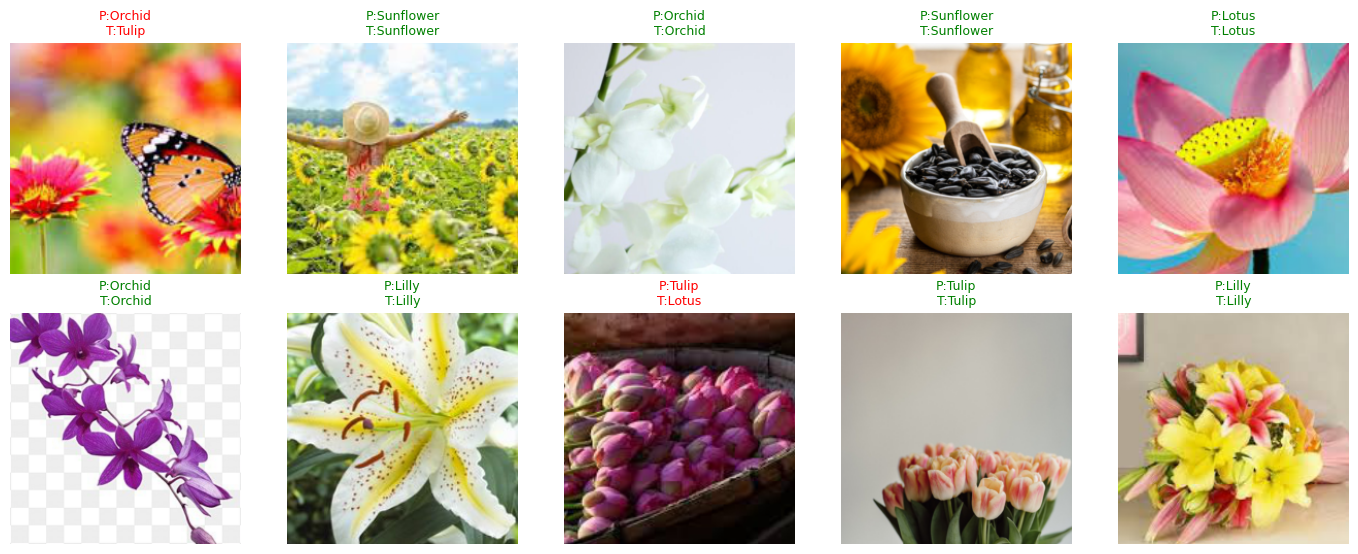

In [ ]:

# ---- Visualize a few predictions ----
import math, random
def denormalize(img_tensor, mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)):
    if isinstance(mean, tuple): mean = torch.tensor(mean, device=img_tensor.device).view(3,1,1)
    if isinstance(std, tuple):  std  = torch.tensor(std,  device=img_tensor.device).view(3,1,1)
    return (img_tensor * std + mean).clamp(0,1)

@torch.no_grad()
def show_predictions_balanced(model, dataset, class_names, k_per_class=2, max_total=12):
    model.eval()
    targets = dataset.targets if hasattr(dataset, "targets") else [y for _, y in dataset]
    per_class = {c: [] for c in range(len(class_names))}
    for idx, y in enumerate(targets):
        per_class[int(y)].append(idx)

    chosen = []
    for c in range(len(class_names)):
        pool = per_class[c]
        if pool:
            k = min(k_per_class, len(pool))
            chosen += random.sample(pool, k)
    random.shuffle(chosen)
    chosen = chosen[:max_total]

    imgs, labels = [], []
    for i in chosen:
        img, y = dataset[i]
        imgs.append(img); labels.append(y)
    if not imgs:
        print("No images sampled. Check dataset path.");
    else:
        batch = torch.stack(imgs).to(device)
        labels = torch.tensor(labels, device=device)
        preds = model(batch).argmax(1)

        n = len(imgs); cols = min(5, n); rows = math.ceil(n/cols)
        plt.figure(figsize=(2.8*cols, 2.8*rows))
        for i in range(n):
            plt.subplot(rows, cols, i+1)
            disp = denormalize(batch[i].cpu()).permute(1,2,0)
            p, t = class_names[preds[i].item()], class_names[labels[i].item()]
            plt.imshow(disp); plt.axis("off")
            plt.title(f"P:{p}\nT:{t}", fontsize=9, color=("green" if p==t else "red"))
        plt.tight_layout(); plt.show()

show_predictions_balanced(model, test_ds, class_names, k_per_class=2, max_total=20)



## Parameters: GoogLeNet vs VGG‑16 vs AlexNet
- **AlexNet (2012):** ~60–62M parameters, early use of large kernels (11×11, 5×5), split GPUs.
- **VGG‑16 (2014):** ~138M parameters, very deep but uses only 3×3 convs + big fully‑connected tail.
- **GoogLeNet (2014):** ~6.8M parameters, **much fewer** thanks to **Inception** + **1×1 bottlenecks** and **no giant FC classifier**.



## Design Comparison: AlexNet vs VGG‑16 vs GoogLeNet
**Depth & width**
- **AlexNet:** ~8 learnable layers; large early kernels; many params in FC layers.
- **VGG‑16:** 13 conv + 3 FC; uniform 3×3 convs; **very** parameter heavy (~138M).
- **GoogLeNet:** 22 layers deep *effectively* (counting Inception blocks); uses parallel branches with 1×1 bottlenecks → **~6.8M params**.

**Computation & efficiency**
- **AlexNet:** simpler, fast to train but not very parameter efficient.
- **VGG‑16:** heavy compute/memory due to deep stacks + large FC.
- **GoogLeNet:** **efficient**; aux classifiers help gradient flow; fewer params enable deeper nets on 2014 hardware.

**Feature aggregation**
- **AlexNet/VGG:** strictly sequential blocks.
- **GoogLeNet:** **multi‑scale feature extraction in parallel**, concatenated per stage.

**Practical takeaway**
- When you need **strong accuracy under parameter/memory constraints**, GoogLeNet/Inception‑style modules (and its successors) are preferable to VGG‑style designs.  


## What's Next:

**SqueezeNet**: It achieves **AlexNet-level accuracy** with **~50× fewer parameters** (≈**1.25M**), making it ideal for resource-constrained devices.

---
This practical was designed to give you hands‑on experience with **GoogLeNet (Inception v1)**, a clear comparison to **AlexNet** and **VGG‑16**, and practical skills in **fine‑tuning** pretrained models for image classification.
